# Energy Balance Model 

## Heat Equation In Spherical Coordinate 

We can discretize the earth to bands at different latitude. 

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as wdgt
import numpy as np

fig = plt.figure()
global ax
ax = fig.add_subplot(projection='3d')
# Set an equal aspect ratio
ax.set_aspect('equal')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

theta = np.linspace(0, 2 * np.pi, 100)  #longitude 
phi = np.linspace(0, np.pi, 100) #latitude

x = np.outer(np.cos(theta), np.sin(phi)) #x at (theta,phi) is given by sin(phi)cos(theta)
y = np.outer(np.sin(theta), np.sin(phi)) #y at (theta, phi) is given by sin(phi)sin(theta)
z = np.outer(np.ones(np.size(theta)), 296*np.cos(phi)/297) #z at (theta, phi) is given by cos(phi) with a flattening 

# Plot the surface
ax.plot_surface(x, y, z, zorder=1)

#the resolution of the discretization
N = wdgt.IntSlider(value=5, min=5, max=30, step=1)

lines = []

def plot_discretization(N):
    global lines
    if len(lines) > 0:
        for line in lines:
            line.remove()
    lines = []
    for phi_ in np.linspace(0, np.pi, N):
        x = np.cos(theta) * np.sin(phi_) 
        y = np.sin(theta) * np.sin(phi_)
        z = 296*np.cos(phi_)/297
        new_line = (ax.plot(x, y, z, color='black', linewidth=1, linestyle='--', zorder=3))[0] #plot returns a list
        lines.append(new_line)
    plt.draw()

wdgt.interact(plot_discretization, N=N)
plt.show()

# 1D Heat Equation EBM

In [1]:
import numpy as np
import tqdm
from helpers import *

In [2]:
class oneDimensionalEBM :
    """1D energy balance model with aquaplanet with second order accuracy in space and first order accuarcy in time
    """
    def __init__(self, N, total_it, dt, T_initial):
        #-----------------model hyperparamter-----------------
        self.N = N
        self.total_it = total_it 
        self.dt = dt
        self.dphi = np.pi / N
        
        #----------------physical constants------------------
        #unit : Jday^{-1}m^{-2} #soloar radiation flux density
        self.S0 = 1370 * 0.7 / 4  * 3600 * 24
        self.T_initial = T_initial 
        self.sigma = 5.67 * 1e-8 * 3600 * 24 #unit: Jday^{-1}m^{-2}K^{-4}
        
        #thermal diffuisivity
        self.D_water =  3 * 1e-6 * 3600 * 24 #m^{2}day^{-1} 
        self.C_water = 4000 #400 J/kg/K

        
        #------------------derived constants--------------------
        self.phi : np.ndarray = np.linspace(-np.pi/2+1e-2, np.pi/2-1e-2, self.N) 
        self.cosphi_i = np.cos(self.phi)
        self.cosphi_i_minus_one = shift_numpy_array(np.cos(self.phi), -1)
        self.cosphi_i_plus_one =  shift_numpy_array(np.cos(self.phi), 1)
        
        #-------------allocate resource for result----------------
        self.T_video = np.empty((total_it, N)) + 0.0
        self.T_video[0] = np.ones_like(self.phi) * self.T_initial 
    
    def compute_linear_system(self, T_prev):
        # bias/forcing
        b = (self.S0 * np.abs(np.cos(self.phi)) - self.sigma * (T_prev ** 4))/self.C_water

        # "state-transition matrix"
        diagonal = np.diag(-self.D_water * ((self.cosphi_i_minus_one + self.cosphi_i_plus_one) / (4 * (self.dphi ** 2) * self.cosphi_i)))
        sup_diagonal = np.diag(self.cosphi_i_plus_one[0 : -2] / (4 * (self.dphi ** 2) * self.cosphi_i[0 : -2]) * self.D_water, k = 2)
        sub_diagonal = np.diag(self.cosphi_i_minus_one[2:] / (4 * (self.dphi ** 2 * self.cosphi_i)[2:]) * self.D_water, k = -2)

        A = (diagonal + sup_diagonal + sub_diagonal) 
        
        # neumann boundary condition by using third order approximation 
        A[self.N-2, self.N-4] = self.D_water * np.cos(self.phi[self.N-1]) / (24 * (self.dphi ** 2) * np.cos(self.phi[self.N-2])) 
        A[1, 3] = self.D_water * np.cos(self.phi[0]) / (24 * (self.dphi ** 2) * np.cos(self.phi[1])) 
        
        A /= self.C_water
        
        return A, b
    
    def explicit_solve(self): 
        """Euler forward step
        """
        for t in tqdm.tqdm(range(1, self.total_it)):
            T_prev = self.T_video[t-1]
            A, b = self.compute_linear_system(T_prev)
            self.T_video[t] = T_prev + (A @ T_prev + b) * self.dt
    
    def backward_solve(self):
        for t in tqdm.tqdm(range(1, self.total_it)):
            T_prev = self.T_video[t-1]
            A, b = self.compute_linear_system(T_prev)
            self.T_video[t] = np.linalg.solve(a=np.eye(self.N) - A*self.dt, b= b*self.dt + T_prev)
            


In [8]:
class oneDimensionalEBM_with_blanket :
    """1D energy balance model with aquaplanet with second order accuracy in space and first order accuarcy in time
    """
    def __init__(self, N, total_it, dt, T_initial_surface, T_initial_blanket):
        #-----------------model hyperparamter-----------------
        self.N = N
        self.total_it = total_it 
        self.dt = dt
        self.dphi = np.pi / N
        
        #----------------physical constants------------------
        #unit : Jday^{-1}m^{-2} #soloar radiation flux density
        self.S0 = 1370 * 0.7 / 4  * 3600 * 24
        self.T_initial_surface = T_initial_surface
        self.T_initial_blanket = T_initial_blanket
        
        self.sigma = 5.67 * 1e-8 * 3600 * 24 #unit: Jday^{-1}m^{-2}K^{-4}
        
        #thermal diffuisivity
        self.D_water =  3 * 1e-6 * 3600 * 24 #m^{2}day^{-1} 
        self.C_water = 4000 # J/kg/K
        
        self.D_air = 5 * 1e-5 * 3600 * 24
        self.C_air = 1000 # J/kg/K

        
        #------------------derived constants--------------------
        self.phi : np.ndarray = np.linspace(-np.pi/2+1e-2, np.pi/2-1e-2, self.N) 
        self.cosphi_i = np.cos(self.phi)
        self.cosphi_i_minus_one = shift_numpy_array(np.cos(self.phi), -1)
        self.cosphi_i_plus_one =  shift_numpy_array(np.cos(self.phi), 1)
        
        #-------------allocate resource for result----------------
        self.T_video_surface = np.empty((total_it, N)) + 0.0
        self.T_video_surface[0] = np.ones_like(self.phi) * self.T_initial_surface
        
        self.T_video_blanket = np.empty((total_it, N)) + 0.0
        self.T_video_blanket[0] = np.ones_like(self.phi) * self.T_initial_blanket
    
    def compute_linear_system(self, T_prev_surface, T_prev_blanket):
        # bias/forcing
        b_surface = (self.S0 * np.abs(np.cos(self.phi)) - self.sigma * (T_prev_surface ** 4) + self.sigma * (T_prev_blanket ** 4))/self.C_water
        b_blanket = (self.S0 * np.abs(np.cos(self.phi)) - self.sigma * (T_prev_blanket ** 4))/self.C_water

        # "state-transition matrix"
        diagonal = np.diag(-self.D_water * ((self.cosphi_i_minus_one + self.cosphi_i_plus_one) / (4 * (self.dphi ** 2) * self.cosphi_i)))
        sup_diagonal = np.diag(self.cosphi_i_plus_one[0 : -2] / (4 * (self.dphi ** 2) * self.cosphi_i[0 : -2]) * self.D_water, k = 2)
        sub_diagonal = np.diag(self.cosphi_i_minus_one[2:] / (4 * (self.dphi ** 2 * self.cosphi_i)[2:]) * self.D_water, k = -2)

        A = (diagonal + sup_diagonal + sub_diagonal) 
        
        # neumann boundary condition by using third order approximation 
        A[self.N-2, self.N-4] = self.D_water * np.cos(self.phi[self.N-1]) / (24 * (self.dphi ** 2) * np.cos(self.phi[self.N-2])) 
        A[1, 3] = self.D_water * np.cos(self.phi[0]) / (24 * (self.dphi ** 2) * np.cos(self.phi[1])) 
        
        A /= self.C_water
        
        return A, b_surface, b_blanket
    
    def explicit_solve(self): 
        """Euler forward step
        """
        for t in tqdm.tqdm(range(1, self.total_it)):
            T_prev_surface = self.T_video_surface[t-1]
            T_prev_blanket = self.T_video_blanket[t-1]
            A, b_surface, b_blanket = self.compute_linear_system(T_prev_surface, T_prev_blanket)
            self.T_video_surface[t] = T_prev_surface + (A @ T_prev_surface + b_surface) * self.dt
            self.T_video_blanket[t] = T_prev_blanket + (A @ T_prev_blanket + b_blanket) * self.dt
    
    def backward_solve(self):
        for t in tqdm.tqdm(range(1, self.total_it)):
            T_prev_surface = self.T_video_surface[t-1]
            T_prev_blanket = self.T_video_blanket[t-1]
            A, b_surface, b_blanket = self.compute_linear_system(T_prev_surface, T_prev_blanket)
            self.T_video_surface[t] = np.linalg.solve(a=np.eye(self.N) - A*self.dt, b= b_surface*self.dt + T_prev_surface)
            self.T_video_blanket[t] = np.linalg.solve(a=np.eye(self.N) - A*self.dt, b= b_blanket*self.dt + T_prev_blanket)
            
            


In [ ]:
model_param = {
    'N' : 500, 
    'total_it' : int(1e5), 
    'dt' : 1e-7, 
    'T_initial' : 273.15
}

EBM_1d = oneDimensionalEBM(**model_param)
EBM_1d.explicit_solve()

T_video = EBM_1d.T_video

100%|██████████| 999999/999999 [00:34<00:00, 29237.07it/s]


In [6]:
model_param_back = {
    'N' : 500, 
    'total_it' : int(1e4), 
    'dt' : 1e-3, 
    'T_initial' : 273.15
}

EBM_1d_back = oneDimensionalEBM(**model_param_back)
EBM_1d_back.backward_solve()

T_video_back = EBM_1d_back.T_video

100%|██████████| 9999/9999 [00:39<00:00, 253.98it/s]
































101it [00:04, 23.92it/s]                        


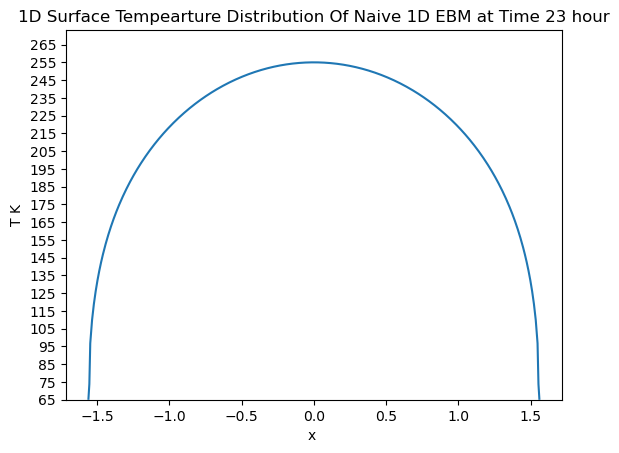

In [48]:
animate_arg = {
    "solution" : T_video_back[:int(1e3)],
    "spatial_discretization" : EBM_1d_back.phi,
    "output_path" : "output/1dheatebm_naive_backward.mp4", 
    "fps" : 20,
    "x_unit" : "", 
    "y_unit" : "K",
    "time_factor" :0.024,
    "coarsen_factor" : int(1e1), # for speed up, plot once per 10 step
    "title" : "Surface Tempearture Distribution Of Naive 1D EBM", 
    "t_unit" : "hour"
}


animate1dPDEsolution(**animate_arg)

100%|██████████| 9999/9999 [01:14<00:00, 134.12it/s]
101it [00:03, 27.06it/s]                        


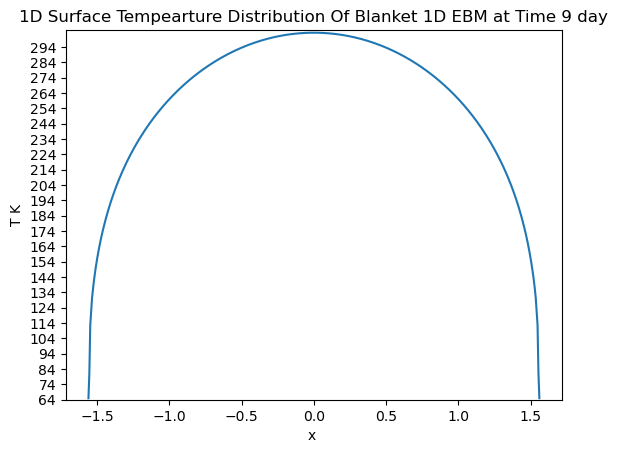

In [20]:
model_param = {
    'N' : 500, 
    'total_it' : int(1e4), 
    'dt' : 1e-3, 
    'T_initial_surface' : 273.15,
    'T_initial_blanket' : 273.15
}

EBM_1d = oneDimensionalEBM_with_blanket(**model_param)
EBM_1d.backward_solve()

T_video_surface = EBM_1d.T_video_surface

animate_arg = {
    "solution" : T_video_surface,
    "spatial_discretization" : EBM_1d.phi,
    "output_path" : "output/1dheatebm.mp4", 
    "fps" : 40,
    "x_unit" : "", 
    "y_unit" : "K",
    "time_factor" :1e-3,
    "coarsen_factor" : int(1e2), # for speed up, plot once per 100 step
    "title" : "Surface Tempearture Distribution Of Blanket 1D EBM", 
    "t_unit" : "day"
}


animate1dPDEsolution(**animate_arg)

In [44]:
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import tqdm

def animate_planet_1dscalar_var(var_video, var_name, 
                                output_path, 
                                fps, 
                                title, 
                                coarsen_factor=1000, 
                                time_unit=None, 
                                time_factor=None, 
                                vmin=None, 
                                vmax=None,):
    fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
    
    total_frames = int(len(var_video)/coarsen_factor)
    
    # Set an equal aspect ratio
    ax.set_aspect('equal')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.set_title(title)
    
    
    theta = np.linspace(0, 2 * np.pi, 100)  #longitude 
    phi = np.linspace(-np.pi/2, np.pi/2, len(var_video[0])) #latitude
    
    
    x = np.outer(np.cos(theta), np.cos(phi)) #x at (theta,phi) is given by sin(phi)cos(theta)
    y = np.outer(np.sin(theta), np.cos(phi)) #y at (theta, phi) is given by sin(phi)sin(theta)
    z = np.outer(np.ones(np.size(theta)), 296*np.sin(phi)/297) #z at (theta, phi) is given by cos(phi) with a flattening 
    
    ax.view_init(elev=15, azim=35) #
    
    if vmin is None : vmin = np.min(var_video)
    if vmax is None : vmax = np.max(var_video)

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm
    tempmap = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    tempmap.set_array([])
    
    pbar = tqdm.tqdm(total=total_frames)
    
    def get_fcolors(t):
        curr_temp = np.outer(np.ones(np.size(theta)), var_video[t])
        fcolors = cmap(norm(curr_temp))
        return fcolors
    
    # Plot the surface
    surface = ax.plot_surface(x, y, z, zorder=1, facecolors=get_fcolors(0))
    cbar = fig.colorbar(tempmap, ax=ax, shrink=0.6)
    cbar.set_label(var_name)
    
    def update(t):
        nonlocal surface
        t = t * coarsen_factor

        if surface is not None:
            surface.remove()
            
        pbar.update(1)
        
        if time_unit is not None:
            time = int(t * coarsen_factor * time_factor)
            ax.set_title(f"{title} {time} ({time_unit})")
        surface = ax.plot_surface(x, y, z, zorder=1,
                                facecolors=get_fcolors(t))
        

    
    result = anim.FuncAnimation(fig, update, frames=total_frames)
    result.save(filename=output_path, fps=fps)

101it [00:37,  2.68it/s]                         


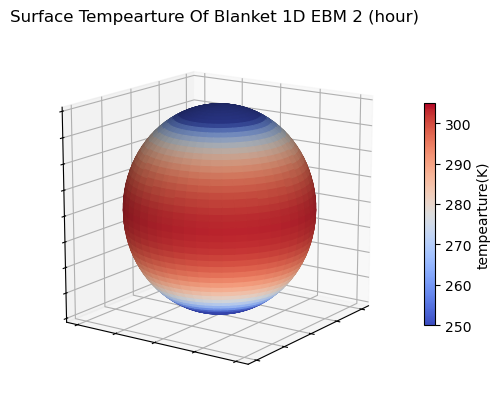

In [45]:
animate_planet_1dscalar_var(var_video=T_video_surface[:int(1e2)],
                            var_name="tempearture(K)", 
                            title="Surface Tempearture Of Blanket 1D EBM", 
                            fps=30, 
                            coarsen_factor=1, 
                            time_unit='hour',
                            time_factor=0.024,
                            vmin = 250, 
                            output_path="output/global_plot_surface.mp4")